In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))
from paths import *


In [ ]:
#Mount drive and locate plant_pipeline image

PP = str(ROOT)
%cd $PP
!ls


Mounted at /content/drive
/content/drive/MyDrive/plant_pipeline
backgrounds	  examples		  gen_composite.py	README.md
build_plant.py	  extract_backgrounds.py  gen_flat.py
build_species.py  gen_canny.py		  plant_pipeline.ipynb


In [ ]:
#Install depndencies
!pip install -q "diffusers>=0.31" "transformers>=4.44" accelerate peft opencv-python numpy pillow


## Build geometry


In [ ]:
'build_species.py writes line art, _flat.png, _mask.png and the prompt files for each seed. Start with a small -n to check the output, then raise it'
'Output goes to out/<species>/ inside the pipeline folder'
#Write line art
%cd $PP
!python build_species.py --species all -n 2 --size 640 -o /tmp/sptest


/content/drive/MyDrive/plant_pipeline
eryngium: 2 -> /tmp/sptest/eryngium
achillea: 2 -> /tmp/sptest/achillea
carpobrotus: 2 -> /tmp/sptest/carpobrotus


achillea achillea_000_flat.png


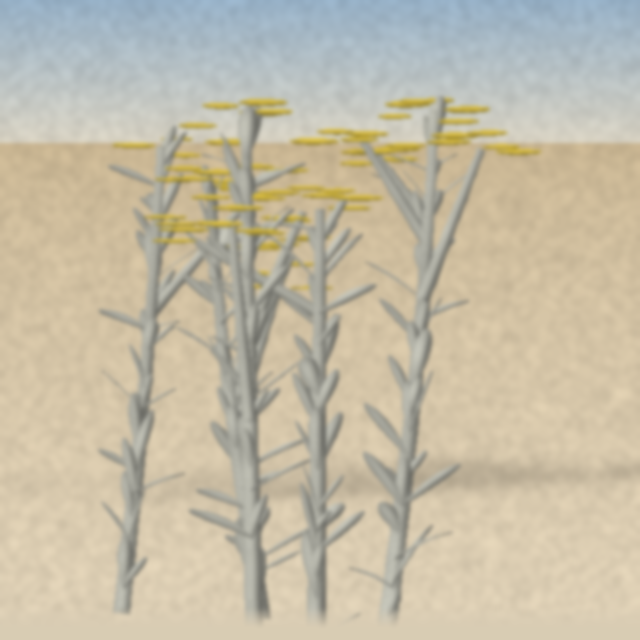

achillea achillea_001_flat.png


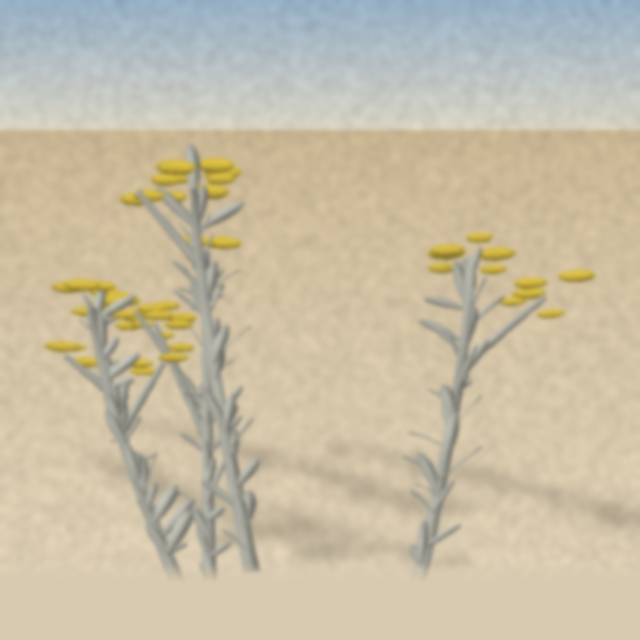

carpobrotus carpobrotus_000_flat.png


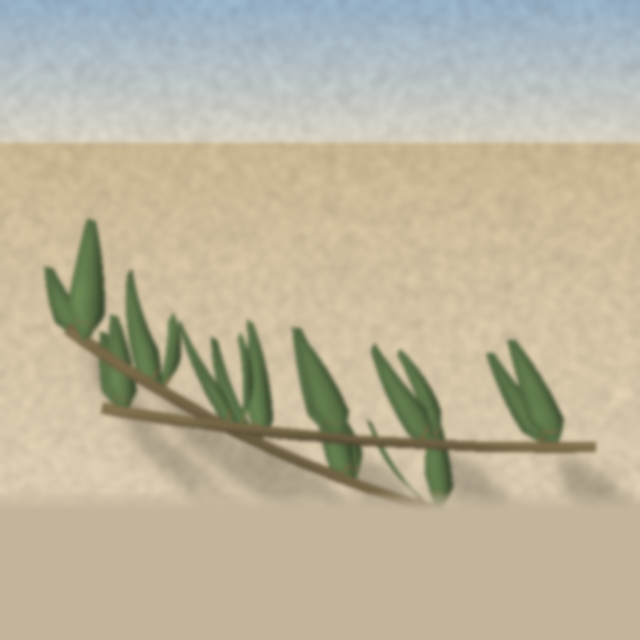

carpobrotus carpobrotus_001_flat.png


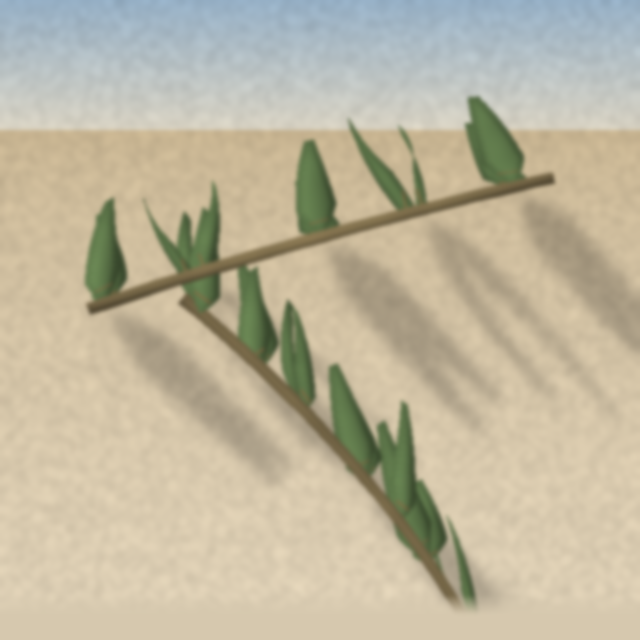

eryngium eryngium_000_flat.png


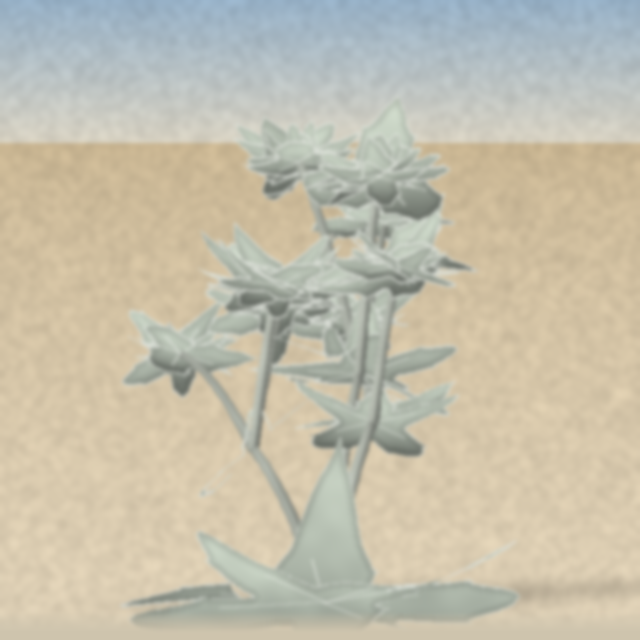

eryngium eryngium_001_flat.png


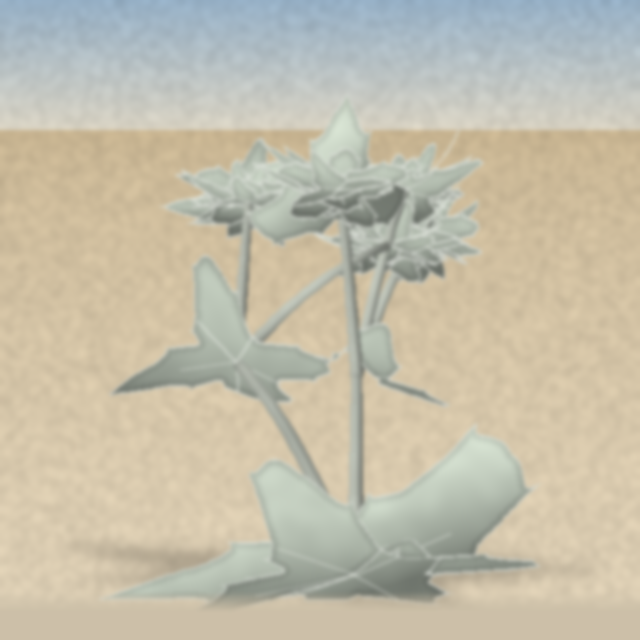

In [ ]:
# Preview the test before performing a full run
import glob
from IPython.display import Image, display

for f in sorted(glob.glob("/tmp/sptest/*/*_flat.png")):
    print(f.split("/")[-2], f.split("/")[-1])
    display(Image(f, width=280))


In [ ]:
# Full build, written to Drive
%cd $PP
!python build_species.py --species all -n 50 --size 1024 -o out


/content/drive/MyDrive/plant_pipeline
eryngium: 50 -> out/eryngium
achillea: 50 -> out/achillea
carpobrotus: 50 -> out/carpobrotus


In [ ]:
# Count of what was built
import glob, os
for d in sorted(glob.glob("out/*/")):
    n = len(glob.glob(d + "*_flat.png"))
    print(f"{os.path.basename(d.rstrip('/')):<14} {n:>3} flats")


achillea        50 flats
carpobrotus     50 flats
eryngium        50 flats


## Generate


In [ ]:
'gen_flat.py runs ControlNet plus img2img over the flats.Results land next to the flats in out/<species>/'
#Runs ControlNet and img2img over the flats of each species
%cd $PP
for s in ["eryngium", "achillea", "carpobrotus"]:
    !python gen_flat.py out/{s} -n 1 --strength 0.85


/content/drive/MyDrive/plant_pipeline
100 spec(s), 1 image(s) each
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100% 1.24k/1.24k [00:00<00:00, 4.16MB/s]

diffusion_pytorch_model.safetensors: downloading bytes:   0% 0.00/2.50G [00:00<?, ?B/s]
diffusion_pytorch_model.safetensors: downloading bytes:   8% 198M/2.50G [00:02<00:09, 231MB/s, 13.3MB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes:  14% 341M/2.50G [00:02<00:06, 346MB/s, 28.3MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file:  10% 256M/2.50G [00:02<00:15, 141MB/s, 12.7MB/s  ] 
diffusion_pytorch_model.safetensors: downloading bytes:  25% 635M/2.50G [00:03<00:03, 470MB/s, 51.1MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file:  16% 402M/2.50G [00:03<00:12, 172MB/s, 

In [ ]:
%cd $PP
!python gen_flat.py out -n 1 --strength 0.85


/content/drive/MyDrive/plant_pipeline
no line-art PNGs found


In [ ]:
# Preview the generated images
import glob
from IPython.display import Image, display

hits = sorted(glob.glob("out/*/*_gen*.png"))
print(len(hits), "generated")
for f in hits[:6]:
    print(f)
    display(Image(f, width=320))


0 generated


## Single species


In [ ]:
#Iterate on a singular species to decrease processing time
SPECIES = "carpobrotus"   # eryngium | achillea | carpobrotus

%cd $PP
!python build_species.py --species $SPECIES -n 5 --size 1024 -o out/$SPECIES
!python gen_flat.py out/$SPECIES -n 1 --strength 0.85


## Canny from real photos


In [ ]:
'Point `SRC` at a folder of real images. Writes to `edges/` in the pipeline folder'
#Writes edges from real photographs using canny edge detection
import cv2, glob, os

SRC = f"{PP}/reference"          # folder of real photographs
DST = f"{PP}/edges"
os.makedirs(DST, exist_ok=True)

paths = [p for ext in ("png", "jpg", "jpeg")
         for p in glob.glob(f"{SRC}/**/*.{ext}", recursive=True)]

if not paths:
    print(f"no images under {SRC}")
else:
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("unreadable:", p)
            continue
        edges = cv2.Canny(cv2.GaussianBlur(img, (5, 5), 0), 50, 150)
        cv2.imwrite(os.path.join(DST, "edges_" + os.path.basename(p)), edges)
    print(f"{len(paths)} images -> {DST}")


## Zip


In [ ]:
'Output is already on Drive, so this is only for pulling a copy locally'
#Produce a zip file for download
import shutil
from google.colab import files

shutil.make_archive("/content/plant_out", "zip", f"{PP}/out")
files.download("/content/plant_out.zip")
